In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import viridis, jet
from netCDF4 import Dataset as NetCDFFile

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import seaborn as sns

import os

In [42]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [35]:
file = NetCDFFile('../../RDS/OCO-2/oco2_GEOS_L3CO2_day_20150116_B10206Ar.nc4')
data = np.squeeze(file.variables['XCO2'][:])
lat = np.squeeze(file.variables['lat'][:])
lon = np.squeeze(file.variables['lon'][:])

lon_reshaped = np.reshape(lon, (1, 576))
lat_reshaped = np.reshape(lat, (361, 1))

new_lon, new_lat = np.broadcast_arrays(lon_reshaped, lat_reshaped)
new_lon = new_lon.flatten()
new_lat = new_lat.flatten()

In [40]:
lonE = 25
lonW = -11
latS = 35
latN = 60

extents = (lonW, lonE, latS, latN)

In [43]:
lonE_sr = find_nearest(lon, lonE)
lonW_sr = find_nearest(lon, lonW)
latS_sr = find_nearest(lat, latS)
latN_sr = find_nearest(lat, latN)

print(lonE_sr, lonW_sr, latS_sr, latN_sr)

328 270 250 300


In [52]:
europe_lr = data[latS_sr:latS_sr+32, lonW_sr:lonW_sr+32]
np.save('europe_lr.npy', np.asarray(europe_lr))

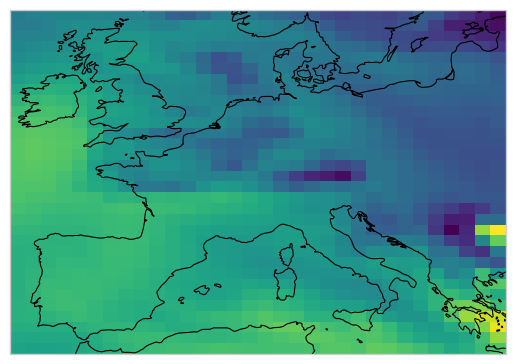

In [53]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.imshow(data[latS_sr:latS_sr+32, lonW_sr:lonW_sr+32], extent=extents, cmap=viridis)

-2.322456566616893e-06 2.0564802980516106e-06


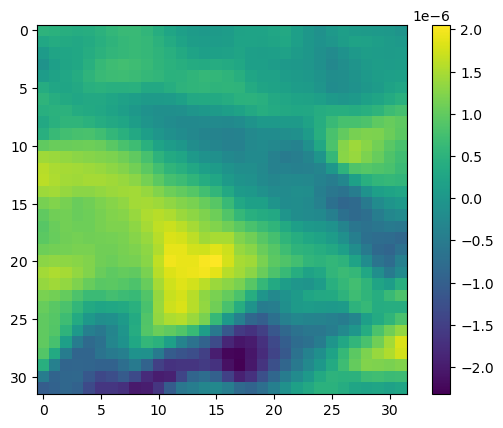

In [37]:
file_test = np.load('Input/XCO2/0_lr.npy')
file_lr = np.expand_dims(file_test, axis=0)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test)
plt.colorbar()


In [3]:
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [4]:
def unnormalize(array_sr, array_lr):
    for i in range(len(array_sr)):
        array_sr[i] = normalize(array_sr[i])
        min = np.min(array_lr[i])
        max = np.max(array_lr[i])
        array_sr[i] = (array_sr[i] * (max - min)) + min
    return array_sr

-3.0314077e-06 7.237941e-07


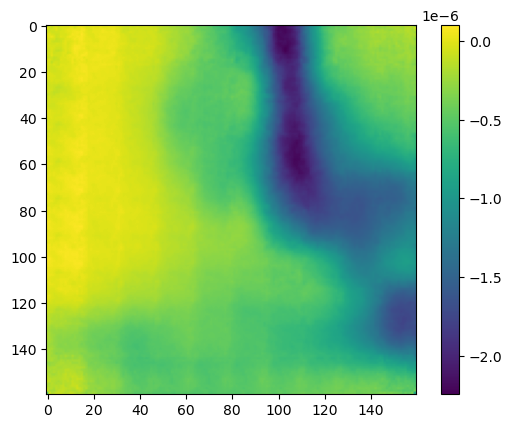

In [7]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/sr/diff/0_lr.npy')
# file_test = np.transpose(file_test, (0, 2, 1))
file_test = unnormalize(file_test, lr)
print(np.min(file_test[0]), np.max(file_test[0]))
plt.imshow(file_test[1])
plt.colorbar()


(313, 10, 10)
-3.0314076866488904e-06 7.237940735648775e-07


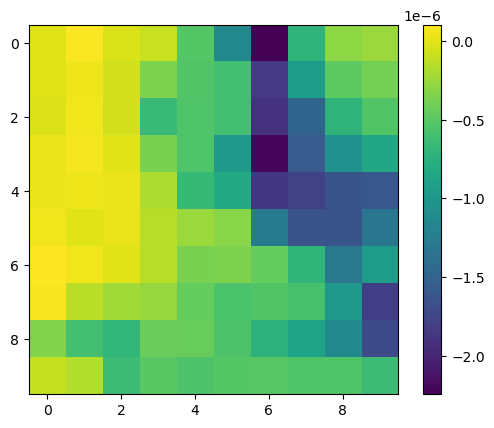

In [6]:
file_test = np.load('../../RDS/ephemeral/difference_xco2_test/lr/diff/0_lr.npy')
# print(np.min(file_test[0]))
print(file_test.shape)
print(np.min(file_test[0]), np.max(file_test[0]))
lr = file_test
plt.imshow(file_test[1])
plt.colorbar()


-2.2608513e-06 2.1352234e-06


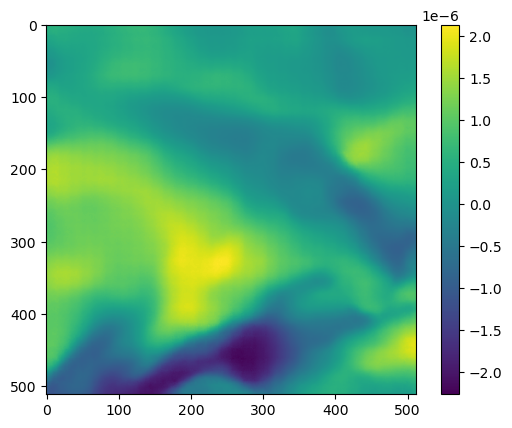

In [36]:
file_test = np.load('../../RDS/dbpn/DBPN_2/Result/XCO2/0_lr.npy')
file_test = unnormalize(np.expand_dims(file_test, axis=0), file_lr)
print(np.min(file_test), np.max(file_test))
plt.imshow(file_test[0])
plt.colorbar()

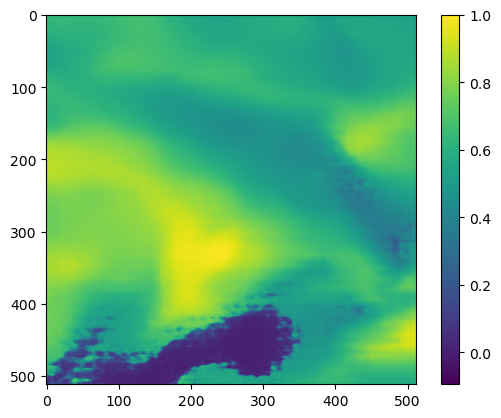

In [4]:
file_test = np.load('Result/XCO2/0_lr_old.npy')
plt.imshow(file_test)
plt.colorbar()

array([0., 1.])

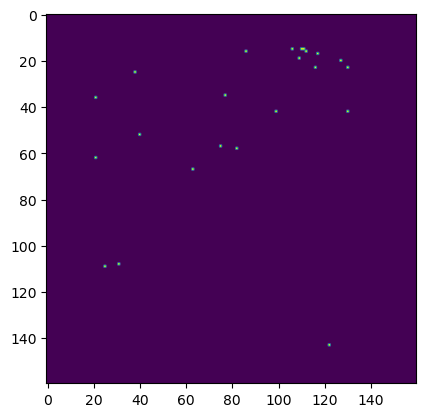

In [2]:
label_sr = np.load('../../RDS/ephemeral/difference_xco2_train/sr/labels/0_sr.npy')
plt.imshow(label_sr)

np.unique(label_sr)

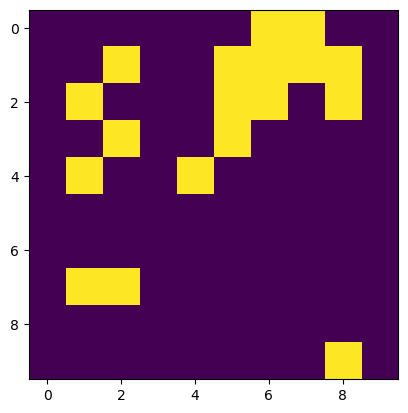

In [3]:
label_lr = np.load('../../RDS/ephemeral/difference_xco2_train/lr/labels/0_lr.npy')
plt.imshow(label_lr)